In [1]:
#导入库
import numpy as np
import torch
from torch.utils.data import DataLoader
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#1.数据预处理
train = pd.read_csv(r'C:\文件\资料\深度学习\PyTorch深度学习实践\练习\titanic\train.csv')
train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [3]:
#检查缺失情况
train.isnull().mean() * 100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [4]:
# 在训练代码中（填充Age和Embarked之后）记录
age_mean = train['Age'].mean()
embarked_mode = train['Embarked'].mode()[0]
fare_mean = train['Fare'].mean()   # 用于填充测试集中的缺失Fare（原始值）

#Age使用平均值填充;Embarked使用最多的登船点;Cabin缺失过多去除该列
train['Age'] = train['Age'].fillna(train['Age'].mean())
train['Embarked'] = train['Embarked'].fillna(train['Embarked'].mode()[0])
train.drop('Cabin',axis=1,inplace=True)
#再次检查缺失情况
print(train.isnull().mean() * 100)
train

PassengerId    0.0
Survived       0.0
Pclass         0.0
Name           0.0
Sex            0.0
Age            0.0
SibSp          0.0
Parch          0.0
Ticket         0.0
Fare           0.0
Embarked       0.0
dtype: float64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,111369,30.0000,C


In [5]:
#成员编号和名字与预测无关，故删去,票价可用房型替代,删去
train.drop(['PassengerId','Name','Ticket'],axis=1,inplace=True)
#将字符串映射为实数
#Sex:male->0,female->1
train['Sex'] = train['Sex'].map({'male':0,'female':1})
#Embarked:拆成两列(一共三种可能，如果两列数值都为0，则自动为第三种)
embarked_dummies = pd.get_dummies(train['Embarked'], prefix='Embarked', drop_first=True)
train = pd.concat([train, embarked_dummies], axis=1)
train.drop(['Embarked'],axis=1,inplace=True)
#Fare数值过大,数值加一取对数
train['Fare'] = np.log1p(train['Fare'])
train

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.000000,1,0,2.110213,False,True
1,1,1,1,38.000000,1,0,4.280593,False,False
2,1,3,1,26.000000,0,0,2.188856,False,True
3,1,1,1,35.000000,1,0,3.990834,False,True
4,0,3,0,35.000000,0,0,2.202765,False,True
...,...,...,...,...,...,...,...,...,...
886,0,2,0,27.000000,0,0,2.639057,False,True
887,1,1,1,19.000000,0,0,3.433987,False,True
888,0,3,1,29.699118,1,2,3.196630,False,True
889,1,1,0,26.000000,0,0,3.433987,False,False


In [6]:
# 加载测试集
test = pd.read_csv(r'C:\文件\资料\深度学习\PyTorch深度学习实践\练习\titanic\test.csv')

# 保存 PassengerId，用于最终输出
passenger_ids = test['PassengerId']

# 与训练集相同的预处理步骤
# 1) 删除 Cabin（与训练集一致）
test.drop('Cabin', axis=1, inplace=True)

# 2) 填充 Age 缺失值（使用训练集均值）
test['Age'] = test['Age'].fillna(age_mean)

# 3) 填充 Embarked 缺失值（使用训练集众数）
test['Embarked'] = test['Embarked'].fillna(embarked_mode)

# 4) 填充 Fare 缺失值（使用训练集均值，原始票价）
test['Fare'] = test['Fare'].fillna(fare_mean)

# 5) 编码 Sex
test['Sex'] = test['Sex'].map({'male': 0, 'female': 1})

# 6) Embarked 独热编码（与训练集一致，drop_first=True）
embarked_dummies = pd.get_dummies(test['Embarked'], prefix='Embarked', drop_first=True)
test = pd.concat([test, embarked_dummies], axis=1)
test.drop(['Embarked'], axis=1, inplace=True)

# 7) Fare 取对数（+1 后取 log）
test['Fare'] = np.log1p(test['Fare'])

# 8) 删除与预测无关的列（与训练集一致）
test.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)

# 确保特征顺序与训练时相同（训练时特征顺序为 Pclass, Sex, Age, SibSp, Parch, Fare, Embarked_Q, Embarked_S）
# 可以按此顺序提取
feature_cols = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']
test = test[feature_cols]

# 将测试数据转换为 PyTorch Tensor
x_test = torch.from_numpy(test.values.astype(np.float32))

In [7]:
#构造训练集

xy = train.values.astype(np.float32)
x_data = torch.from_numpy(xy[:,1:])
y_data = torch.from_numpy(xy[:, [0]])
dataset = torch.utils.data.TensorDataset(x_data,y_data)

In [8]:
#定义模型
class Model(torch.nn.Module):
    def __init__(self):
        super(Model, self).__init__()
        self.linear1 = torch.nn.Linear(8, 64)
        self.linear2 = torch.nn.Linear(64, 32)
        self.linear3 = torch.nn.Linear(32, 16)
        self.linear4 = torch.nn.Linear(16, 8)
        self.linear5 = torch.nn.Linear(8, 4)
        self.linear6 = torch.nn.Linear(4, 1)
        self.sigmoid = torch.nn.Sigmoid()
        self.leaky_relu = torch.nn.LeakyReLU(0.01) 

    def forward(self, x):
        x = self.leaky_relu(self.linear1(x))
        x = self.leaky_relu(self.linear2(x))
        x = self.leaky_relu(self.linear3(x))
        x = self.leaky_relu(self.linear4(x))
        x = self.leaky_relu(self.linear5(x))
        x = self.sigmoid(self.linear6(x))
        return x

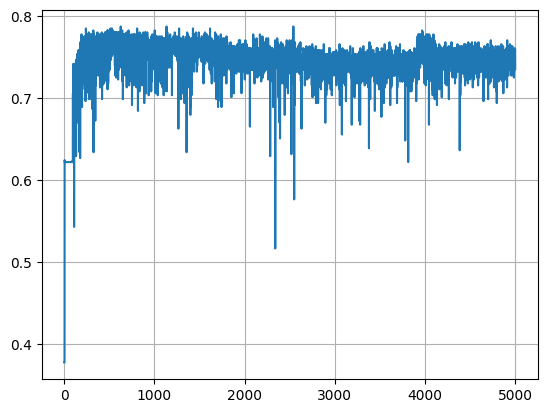

In [9]:
train_epoch = []
train_accuracy = []

if __name__ == '__main__':
    train_loader = DataLoader(
        dataset=dataset,
        batch_size=32,
        shuffle=True,
        num_workers=0
    )

    model = Model()
    criterion = torch.nn.BCELoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01,momentum=0.5)

    # 训练循环
    for epoch in range(5000):
        for i, data in enumerate(train_loader, 0):
            inputs, labels = data

            # 前向传播
            y_pred = model(inputs)
            loss = criterion(y_pred, labels)

            # 反向传播
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # 模型切换到评估模式（禁用 dropout / batch norm 等）
        model.eval()
        with torch.no_grad():
            outputs = model(x_test)
            predictions = (outputs >= 0.5).float().numpy().flatten().astype(int)  # 0 或 1

            # 创建提交 DataFrame
            submission = pd.DataFrame({
                'PassengerId': passenger_ids,
                'Survived': predictions
            })

            # 保存为 CSV（无索引）
            submission.to_csv('submission.csv', index=False)

            answer = pd.read_csv(r'C:\文件\资料\深度学习\PyTorch深度学习实践\练习\submission.csv')
            code = pd.read_csv(r'C:\文件\资料\深度学习\PyTorch深度学习实践\练习\Trueanswer.csv')
            answer,code
            equal_count = (answer['Survived'] == code['Survived']).sum()
            total = len(answer)
            ratio = equal_count / total

            train_epoch.append(epoch)
            train_accuracy.append(ratio)

plt.plot(train_epoch,train_accuracy)
plt.grid()
plt.show()